# U.S. Hospital ED Performance — Python Analysis

Hospital quality data published by CMS exists publicly but is fragmented across
reporting programs. This notebook consolidates emergency department throughput
and hospital star ratings to answer two questions:

1. **Does a hospital's CMS star rating predict its ED wait time?**
2. **How much of the variation in ED wait time is explained by which state a
   hospital is in, versus the individual hospital itself?**

The SQL layer (`sql/`) produces the views behind the Tableau dashboard. This
notebook works from the same two raw CMS files independently, as a second,
Python-based path to the same cohort — useful both as a cross-check on the SQL
and to produce the statistical detail (correlation, significance, variance
decomposition) that doesn't belong in a dashboard tooltip.

**Data sources:**
- `Timely_and_Effective_Care-Hospital.csv` — one row per hospital per measure.
  Measure used here: `OP_18b`, median ED wait time in minutes.
- `HospInfo_2026.csv` — CMS Hospital General Information, released 2026-08-13,
  last modified 2026-07-22. Star ratings (1-5) and hospital type/state.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Load and join

Both files are read with `dtype=str` on the ID columns. `Facility ID` is
zero-padded (e.g. `"010001"`) and a few IDs are alphanumeric (Rural Emergency
Hospital conversions, e.g. `"01014F"`) — reading as string preserves both
correctly with no extra handling needed.


In [2]:
timely = pd.read_csv("../data/raw/Timely_and_Effective_Care-Hospital.csv", dtype=str)
hospinfo = pd.read_csv("../data/raw/HospInfo_2026.csv", dtype=str)

print(f"{len(timely):,} measure rows, {timely['Facility ID'].nunique():,} distinct facilities")
print(f"{len(hospinfo):,} hospitals in the current CMS Hospital General Information file")


138,173 measure rows, 4,660 distinct facilities
5,419 hospitals in the current CMS Hospital General Information file


## 2. Cohort definition

Same rule as `00_cohort_definitions.sql`: a hospital's `OP_18b` score counts
if the score is a valid number and the sample size is at least 30 patients.
No upper cap — large samples are states reporting full counts rather than a
true sample, not data errors (checked in the SQL work: removing a 5,000 cap
moved no state average by more than 2.5 minutes).


In [3]:
ed = timely[timely["Measure ID"] == "OP_18b"].copy()
ed = ed[ed["Score"].str.match(r"^\d+$", na=False)]
ed["ed_wait_minutes"] = ed["Score"].astype(int)
ed["patient_sample"] = pd.to_numeric(ed["Sample"], errors="coerce")
ed = ed[ed["patient_sample"] >= 30]
ed = ed[["Facility ID", "State", "ed_wait_minutes", "patient_sample"]]

print(f"{len(ed):,} hospitals pass the cohort filter (Score numeric, Sample >= 30)")


4,073 hospitals pass the cohort filter (Score numeric, Sample >= 30)


## 3. Join to hospital attributes

Inner join on `Facility ID`, then drop hospitals with no star rating —
matches `view3_rating_vs_wait.sql`.


In [4]:
df = ed.merge(
    hospinfo[["Facility ID", "Facility Name", "Hospital Type", "Hospital overall rating"]],
    on="Facility ID", how="inner"
)
df = df.rename(columns={"Hospital overall rating": "star_rating"})
df = df[df["star_rating"] != "Not Available"].copy()
df["star_rating"] = df["star_rating"].astype(int)

print(f"{len(df):,} hospitals with both a valid ED wait time and a star rating")
df.head()


2,964 hospitals with both a valid ED wait time and a star rating


,Facility ID,State,ed_wait_minutes,patient_sample,Facility Name,Hospital Type,star_rating
0,010001,AL,217,395,SOUTHEAST HEALTH MEDICAL CENTER,Acute Care Hospitals,4
1,010005,AL,141,1165,MARSHALL MEDICAL CENTERS,Acute Care Hospitals,3
2,010006,AL,144,320,NORTH ALABAMA MEDICAL CENTER,Acute Care Hospitals,2
3,010007,AL,128,1048,MIZELL MEMORIAL HOSPITAL,Acute Care Hospitals,1
4,010011,AL,156,254,ST. VINCENT'S EAST,Acute Care Hospitals,3


## 4. Does star rating predict ED wait time?

Pearson correlation between `star_rating` (1-5) and `ed_wait_minutes`.


In [5]:
r, p = stats.pearsonr(df["star_rating"], df["ed_wait_minutes"])
r_squared = r ** 2

print(f"Pearson r        = {r:.4f}")
print(f"p-value          = {p:.4f}")
print(f"r-squared        = {r_squared:.4%}")


Pearson r        = -0.0407
p-value          = 0.0267
r-squared        = 0.1658%


**Interpretation.** The p-value (~0.03) says this correlation is very
unlikely to be exactly zero — but at n≈2,900, even a tiny effect clears
significance. r² is the number that actually matters here: star rating
explains under 0.2% of the variation in ED wait time. That's a real,
detectable relationship and a practically useless one at the same time.
**Current CMS star ratings are not a meaningful predictor of a hospital's ED
wait time.**

Worth noting why this differs from an earlier pass at this same question
using an older, undated `HospInfo.csv`: that file's ratings turned out to be
years stale relative to the 2024-25 wait-time data. Of the hospitals present
in both files, 42% have a different star rating in the current release. With
the outdated ratings, r was -0.205 — a correlation that mostly reflected
comparing wait times against ratings from a different era, not a real
relationship. This is the kind of thing a stale join silently gets wrong.


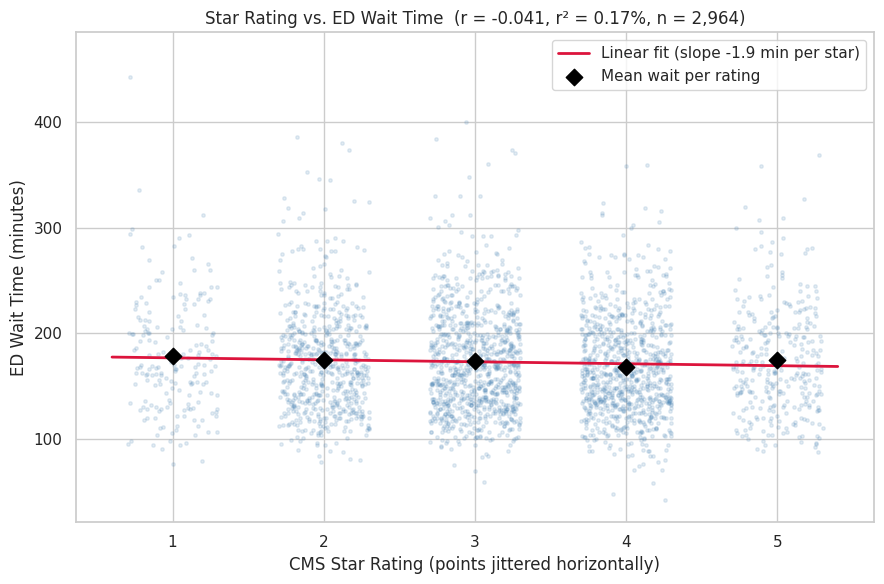

In [6]:
rng = np.random.default_rng(42)
jitter = rng.uniform(-0.3, 0.3, len(df))
means = df.groupby("star_rating")["ed_wait_minutes"].mean()
slope, intercept = np.polyfit(df["star_rating"], df["ed_wait_minutes"], 1)
xs = np.array([0.6, 5.4])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df["star_rating"] + jitter, df["ed_wait_minutes"], s=6, alpha=0.15, color="steelblue")
ax.plot(xs, intercept + slope * xs, color="crimson", linewidth=2, label=f"Linear fit (slope {slope:.1f} min per star)")
ax.scatter(means.index, means.values, marker="D", s=70, color="black", zorder=3, label="Mean wait per rating")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("CMS Star Rating (points jittered horizontally)")
ax.set_ylabel("ED Wait Time (minutes)")
ax.set_title(f"Star Rating vs. ED Wait Time  (r = {r:.3f}, r\u00b2 = {r_squared:.2%}, n = {len(df):,})")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../docs/screenshots/scatter_star_rating.png", dpi=150)
plt.show()


## 5. State vs. within-state variation

The dashboard's state map (View 1) shows large differences between states.
But how much of a hospital's wait time is explained by *which state it's in*,
versus factors specific to that individual hospital? A variance decomposition
answers this directly.


In [7]:
# Uses the full ED cohort (all 4,073 hospitals with a valid OP_18b score), not just the
# star-rated subset, to match View 4's population exactly.
ed["state_avg_wait"] = ed.groupby("State")["ed_wait_minutes"].transform("mean")

total_var = ed["ed_wait_minutes"].var()
within_state_var = (ed["ed_wait_minutes"] - ed["state_avg_wait"]).var()
within_share = within_state_var / total_var

print(f"Share of total wait-time variance that is WITHIN states: {within_share:.1%}")
print(f"Share that is BETWEEN states:                            {1 - within_share:.1%}")


Share of total wait-time variance that is WITHIN states: 72.8%
Share that is BETWEEN states:                            27.2%


About three-quarters of the variation in ED wait time happens *within*
a state, between hospitals that share the same state. A state-level average
(the dashboard's map) hides most of the real variation — an individual
hospital's own performance, not its state, is what mostly determines its wait
time. This is why the SQL layer's View 4 benchmarks each hospital against its
in-state peers rather than against other states.


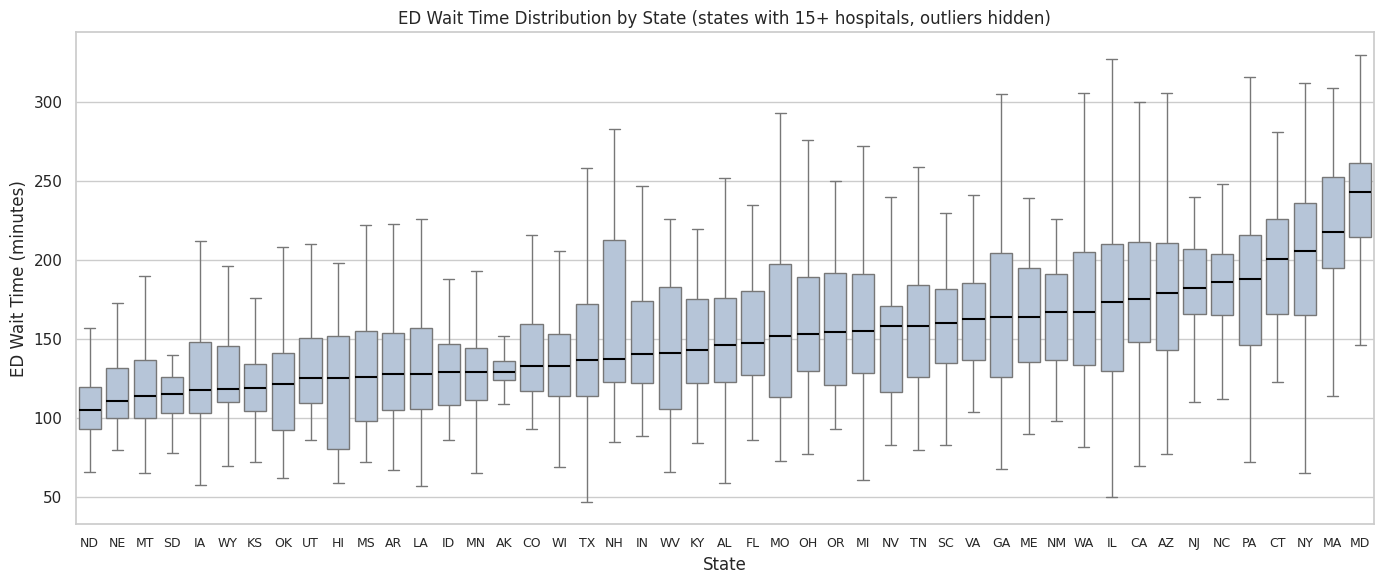

In [8]:
top_states = ed["State"].value_counts()
top_states = top_states[top_states >= 15].index

fig, ax = plt.subplots(figsize=(14, 6))
order = ed[ed["State"].isin(top_states)].groupby("State")["ed_wait_minutes"].median().sort_values().index
sns.boxplot(
    data=ed[ed["State"].isin(top_states)],
    x="State", y="ed_wait_minutes", order=order,
    ax=ax, showfliers=False, color="lightsteelblue",
    medianprops={"color": "black", "linewidth": 1.5}
)
ax.set_xlabel("State")
ax.set_ylabel("ED Wait Time (minutes)")
ax.set_title("ED Wait Time Distribution by State (states with 15+ hospitals, outliers hidden)")
ax.tick_params(axis="x", labelsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../docs/screenshots/boxplot_state_spread.png", dpi=150)
plt.show()


## 6. Wait time by star rating, distribution not just the mean

The correlation says the relationship is weak overall. Looking at the full
distribution per rating shows why: the *spread* within every rating group is
large enough to swamp the small differences between group means.


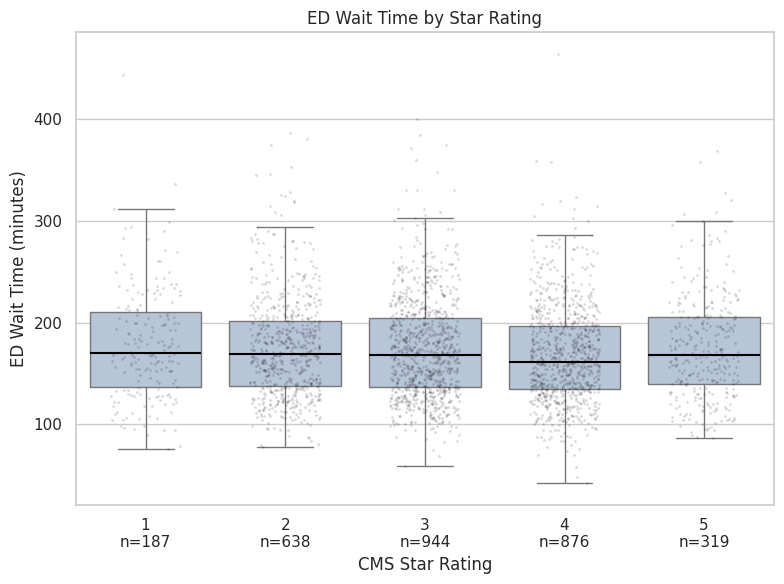

,mean,median,std,count
star_rating,,,,
1,178.4,170.0,54.5,187
2,174.9,169.0,49.5,638
3,173.7,168.0,48.8,944
4,167.9,161.0,47.4,876
5,174.8,168.0,50.5,319


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x="star_rating", y="ed_wait_minutes", ax=ax, color="lightsteelblue", showfliers=False,
            medianprops={"color": "black", "linewidth": 1.5})
sns.stripplot(data=df, x="star_rating", y="ed_wait_minutes", ax=ax, color="black", alpha=0.15, size=2, jitter=0.25)
counts = df["star_rating"].value_counts().sort_index()
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([f"{k}\nn={v:,}" for k, v in counts.items()])
ax.set_xlabel("CMS Star Rating")
ax.set_ylabel("ED Wait Time (minutes)")
ax.set_title("ED Wait Time by Star Rating")
plt.tight_layout()
plt.savefig("../docs/screenshots/box_rating_vs_wait.png", dpi=150)
plt.show()

df.groupby("star_rating")["ed_wait_minutes"].agg(["mean", "median", "std", "count"]).round(1)


## 7. Readmissions: which states have the highest share of readmission measures worse than the national average

Mirrors `view5_readmissions_by_state.sql`. For each hospital, CMS reports how
many readmission measures it was graded on and how many came back Better / No
Different / Worse than the national average. Directly relevant to CMS's Hospital
Readmissions Reduction Program (HRRP), which financially penalizes hospitals for
excess readmissions.

**Metric choice.** A simpler version of this metric flagged a hospital "worse" if
*any* of its measures was worse. The check below shows why that's misleading:
the more measures a hospital is graded on, the more chances it has to be
flagged, so hospitals graded on few measures (mostly Critical Access Hospitals)
look better by construction. The state rate used here counts measures instead:
worse measures / graded measures.


In [10]:
readm_cols = ["Count of Facility READM Measures", "Count of READM Measures Better",
              "Count of READM Measures No Different", "Count of READM Measures Worse"]
readm = hospinfo[["Facility ID", "State", "Hospital Type"] + readm_cols].copy()
for c in readm_cols:
    readm[c] = pd.to_numeric(readm[c], errors="coerce")
readm = readm[readm["Count of Facility READM Measures"] > 0].copy()
readm = readm.rename(columns={
    "Count of Facility READM Measures": "graded",
    "Count of READM Measures Better": "better",
    "Count of READM Measures Worse": "worse",
})

# Bias check: share of hospitals with 1+ worse measure, by number of measures graded
readm["any_worse"] = readm["worse"] > 0
print(f"{len(readm):,} hospitals graded on at least one readmission measure\n")
print("Share of hospitals flagged 'worse' (1+ worse measure), by measures graded:")
print((readm.groupby("graded")["any_worse"].mean() * 100).round(1).to_string())
print("\nAverage measures graded by hospital type:")
print(readm.groupby("Hospital Type")["graded"].mean().round(1).to_string())


4,264 hospitals graded on at least one readmission measure

Share of hospitals flagged 'worse' (1+ worse measure), by measures graded:
graded
1.0      0.6
2.0     13.4
3.0     24.3
4.0     35.5
5.0     46.0
6.0     52.2
7.0     58.7
8.0     62.7
9.0     71.8
10.0    71.3
11.0    77.8

Average measures graded by hospital type:
Hospital Type
Acute Care - Veterans Administration    5.1
Acute Care Hospitals                    7.4
Critical Access Hospitals               3.2


In [11]:
state = readm.groupby("State").agg(
    hospitals_graded=("graded", "size"),
    measures_graded=("graded", "sum"),
    measures_worse=("worse", "sum"),
)
state["pct_measures_worse"] = (100 * state["measures_worse"] / state["measures_graded"]).round(1)
state = state[state["hospitals_graded"] >= 10].sort_values("pct_measures_worse", ascending=False)

national = 100 * readm["worse"].sum() / readm["graded"].sum()
print(f"National rate: {national:.1f}% of graded readmission measures are worse than the national average\n")
print("Highest 5 states (10+ graded hospitals):")
print(state.head()[["hospitals_graded", "measures_graded", "pct_measures_worse"]].to_string())
print("\nLowest 5 states (10+ graded hospitals):")
print(state.tail()[["hospitals_graded", "measures_graded", "pct_measures_worse"]].to_string())


National rate: 12.8% of graded readmission measures are worse than the national average

Highest 5 states (10+ graded hospitals):
       hospitals_graded  measures_graded  pct_measures_worse
State                                                       
PR                   43             70.0                24.3
NJ                   62            525.0                23.0
MA                   57            472.0                22.0
FL                  177           1344.0                21.4
NY                  149           1096.0                20.7

Lowest 5 states (10+ graded hospitals):
       hospitals_graded  measures_graded  pct_measures_worse
State                                                       
WY                   26            127.0                 5.5
MT                   41            194.0                 4.1
SD                   52            196.0                 2.6
ID                   40            202.0                 2.5
UT                   45            2

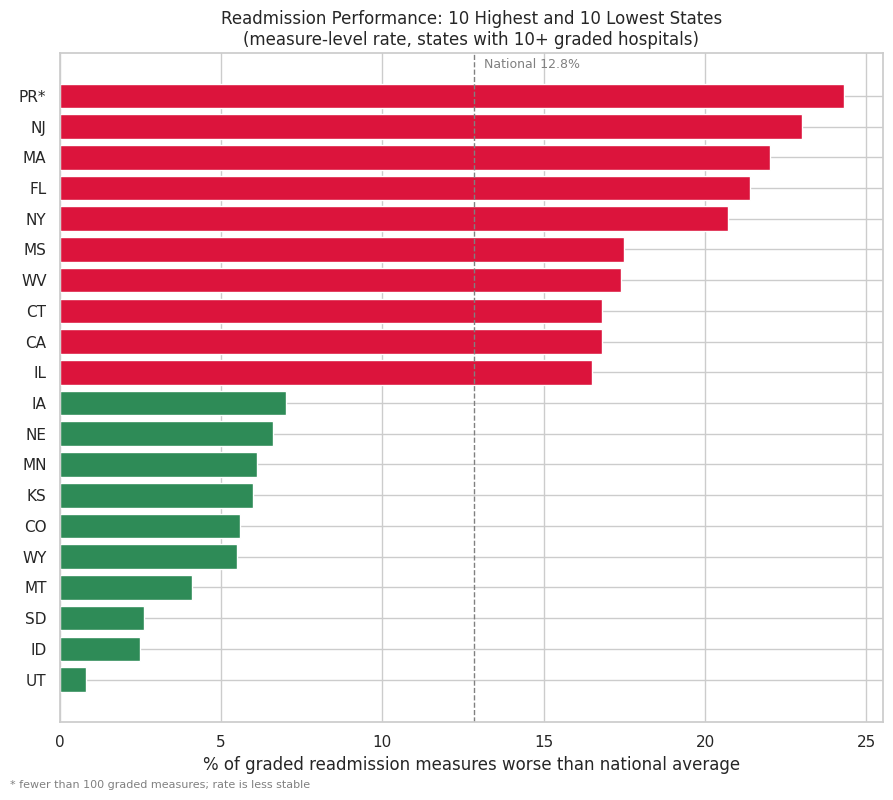

In [12]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_data = pd.concat([state.head(10), state.tail(10)])["pct_measures_worse"]
colors = ["crimson"] * 10 + ["seagreen"] * 10
ax.barh(plot_data.index, plot_data.values, color=colors)
ax.axvline(national, color="gray", linestyle="--", linewidth=1)
ax.invert_yaxis()
ax.text(national + 0.3, -0.9, f"National {national:.1f}%", color="gray", fontsize=9)
small = state.loc[plot_data.index, "measures_graded"] < 100
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels([f"{st}*" if small[st] else st for st in plot_data.index])
if small.any():
    fig.text(0.01, 0.005, "* fewer than 100 graded measures; rate is less stable", fontsize=8, color="gray")
ax.set_xlabel("% of graded readmission measures worse than national average")
ax.set_title("Readmission Performance: 10 Highest and 10 Lowest States\n(measure-level rate, states with 10+ graded hospitals)")
plt.tight_layout()
plt.savefig("../docs/screenshots/readmissions_by_state.png", dpi=150)
plt.show()


## Summary

- **Star rating is not a useful predictor of ED wait time** (r = -0.04,
  r² = 0.17%), despite reaching statistical significance at this sample size.
  An earlier version of this analysis found r = -0.21; that result came from
  joining current wait times to years-stale star ratings.
- **About 73% of ED wait-time variance is within states**, not between them.
  Hospitals in the same state differ far more than state averages suggest.
- **Readmission performance varies by state.** Nationally, 12.8% of graded
  readmission measures are worse than the national average. New Jersey,
  Massachusetts, Florida and New York run at roughly 21-23%; Utah, Idaho and
  South Dakota run under 3%. Puerto Rico has the highest rate (24.3%) but on
  only 70 graded measures.

These findings describe where performance differs, not why. Section 5's
within-state spread, in particular, has not been tested against hospital
size or ED volume.
